# CogniFlow - Stage 3: Multimodal Fusion & XGBoost Classifier
Fuses Stage 1 task features with Stage 2 behavioral features and trains
an XGBoost classifier to predict abandonment risk. Outputs AUC-ROC,
feature importance, and the four-profile monotonic ordering validation.

In [1]:
!pip install -q xgboost scikit-learn pandas numpy matplotlib seaborn

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    roc_auc_score, roc_curve, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.preprocessing import LabelEncoder
np.random.seed(42)
print('Imports OK')

Imports OK


## Step 1 - Load Stage 1 & Stage 2 Data

In [ ]:
import os

BASE = None
for root, dirs, files in os.walk('/kaggle/input/'):
    if 'task_dataset.csv' in files:
        BASE = root
        break
print(f'Found data at: {BASE}')

task_df    = pd.read_csv(f'{BASE}/task_dataset.csv')
visual_df  = pd.read_csv(f'{BASE}/visual_features.csv')

print(f'Stage 1 tasks:    {len(task_df)} rows, columns: {task_df.columns.tolist()}')
print(f'Stage 2 sessions: {len(visual_df)} rows, columns: {visual_df.columns.tolist()}')

Found data at: /kaggle/input/datasets/tejasgovind/cogniflow-outputs
Stage 1 tasks:    400 rows, columns: ['complexity_score', 'estimated_steps', 'priority_level', 'recommendation', 'task_description', 'priority_encoded']
Stage 2 sessions: 100 rows, columns: ['profile', 'session_id', 'avg_gaze', 'gaze_variance', 'avg_head_pose', 'avg_eye_openness', 'avg_posture_score', 'avg_fidget_score', 'cognitive_index', 'visual_state']


## Step 2 - Build Fused Training Dataset

In [ ]:
TASK_FEATURES = ['complexity_score', 'estimated_steps', 'priority_encoded']

BEHAVIORAL_FEATURES = ['avg_gaze', 'avg_head_pose', 'avg_eye_openness', 'gaze_variance']

ALL_FEATURES = TASK_FEATURES + BEHAVIORAL_FEATURES

task_df['_key'] = 1
visual_df['_key'] = 1
fused = pd.merge(task_df[TASK_FEATURES + ['_key']],
                 visual_df[BEHAVIORAL_FEATURES + ['profile', '_key']],
                 on='_key').drop('_key', axis=1)

def label_row(row):
    complexity_norm = (row['complexity_score'] - 1) / 4
    gaze_risk       = max(0, (0.75 - row['avg_gaze']) / 0.75)
    variance_risk   = min(1, row['gaze_variance'] / 0.15)
    eye_risk        = max(0, (0.025 - row['avg_eye_openness']) / 0.025)
    
    risk_score = (
        0.35 * complexity_norm +
        0.30 * gaze_risk +
        0.20 * variance_risk +
        0.15 * eye_risk
    )
    risk_score += np.random.normal(0, 0.05)
    return int(risk_score >= 0.45)

fused['abandonment_risk'] = fused.apply(label_row, axis=1)

pos = fused[fused['abandonment_risk'] == 1]
neg = fused[fused['abandonment_risk'] == 0]
n = min(1000, len(pos), len(neg))
df_train = pd.concat([
    pos.sample(n, random_state=42),
    neg.sample(n, random_state=42)
]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f'Fused dataset: {len(fused)} total rows')
print(f'Training set:  {len(df_train)} rows (balanced)')
print(f'Class distribution:')
print(df_train['abandonment_risk'].value_counts())
print(f'\nFeatures: {ALL_FEATURES}')

Fused dataset: 40000 total rows
Training set:  2000 rows (balanced)
Class distribution:
abandonment_risk
0    1000
1    1000
Name: count, dtype: int64

Features: ['complexity_score', 'estimated_steps', 'priority_encoded', 'avg_gaze', 'avg_head_pose', 'avg_eye_openness', 'gaze_variance']


## Step 3 - Train XGBoost Classifier

In [5]:
X = df_train[ALL_FEATURES]
y = df_train['abandonment_risk']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

print('Model trained.')

Model trained.


## Step 4 - Evaluation Metrics

In [ ]:
y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred       = model.predict(X_test)

auc = roc_auc_score(y_test, y_pred_proba)
print(f'AUC-ROC: {auc:.4f}')

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X, y, cv=cv, scoring='roc_auc')
print(f'5-Fold CV AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['No Risk', 'At Risk']))

AUC-ROC: 0.9578
5-Fold CV AUC: 0.9563 ± 0.0083

Classification Report:
              precision    recall  f1-score   support

     No Risk       0.92      0.87      0.89       200
     At Risk       0.88      0.93      0.90       200

    accuracy                           0.90       400
   macro avg       0.90      0.90      0.90       400
weighted avg       0.90      0.90      0.90       400



## Step 5 - ROC Curve

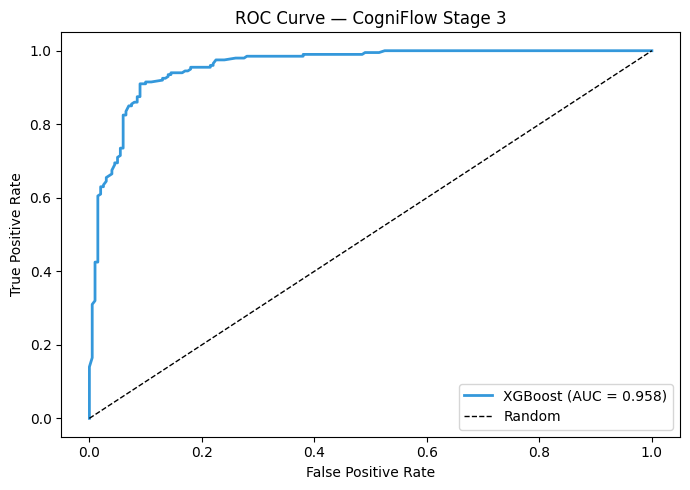

Saved stage3_roc_curve.png


In [7]:
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='#3498db', lw=2, label=f'XGBoost (AUC = {auc:.3f})')
plt.plot([0,1],[0,1], 'k--', lw=1, label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — CogniFlow Stage 3')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('/kaggle/working/stage3_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved stage3_roc_curve.png')

## Step 6 - Feature Importance

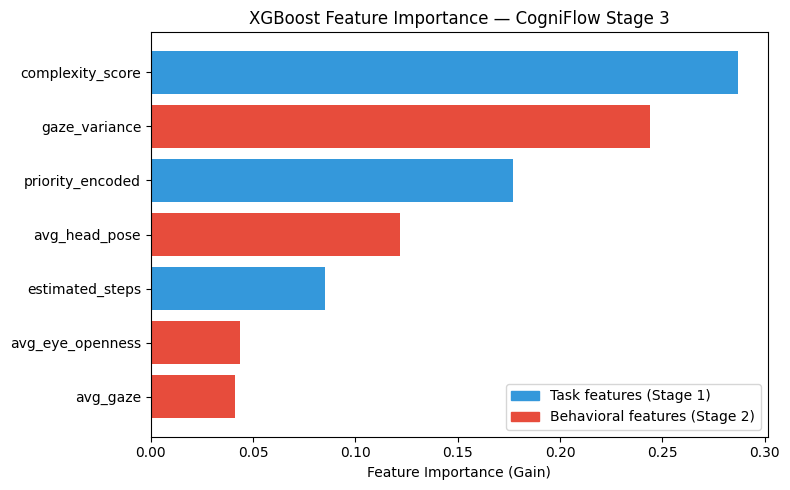

Saved stage3_feature_importance.png
         feature  importance
complexity_score    0.287113
   gaze_variance    0.243752
priority_encoded    0.177233
   avg_head_pose    0.121916
 estimated_steps    0.085072
avg_eye_openness    0.043548
        avg_gaze    0.041366


In [8]:
importance = pd.DataFrame({
    'feature': ALL_FEATURES,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=True)

colors = ['#e74c3c' if f in BEHAVIORAL_FEATURES else '#3498db' for f in importance['feature']]

plt.figure(figsize=(8, 5))
bars = plt.barh(importance['feature'], importance['importance'], color=colors)
plt.xlabel('Feature Importance (Gain)')
plt.title('XGBoost Feature Importance — CogniFlow Stage 3')
from matplotlib.patches import Patch
legend = [
    Patch(color='#3498db', label='Task features (Stage 1)'),
    Patch(color='#e74c3c', label='Behavioral features (Stage 2)')
]
plt.legend(handles=legend)
plt.tight_layout()
plt.savefig('/kaggle/working/stage3_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved stage3_feature_importance.png')
print(importance.sort_values('importance', ascending=False).to_string(index=False))

## Step 7 - Confusion Matrix

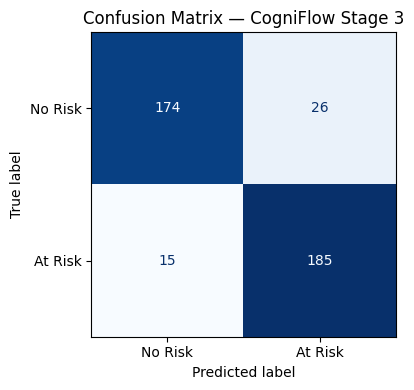

Saved stage3_confusion_matrix.png


In [9]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Risk', 'At Risk'])
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — CogniFlow Stage 3')
plt.tight_layout()
plt.savefig('/kaggle/working/stage3_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved stage3_confusion_matrix.png')

## Step 8 - Four-Profile Monotonic Ordering Test
Per the paper's evaluation protocol: the same high-complexity anchor task
is run against all four mock profiles. Correct order:
highly_focused < moderate < fatigued < easily_distracted

In [10]:
anchor_task = {
    'complexity_score': 5,
    'estimated_steps': 12,
    'priority_encoded': 2
}

mock_profiles = {
    'highly_focused':    {'avg_gaze': 0.85, 'avg_head_pose': 0.88, 'avg_eye_openness': 0.030, 'gaze_variance': 0.02},
    'moderate':          {'avg_gaze': 0.70, 'avg_head_pose': 0.75, 'avg_eye_openness': 0.028, 'gaze_variance': 0.06},
    'fatigued':          {'avg_gaze': 0.65, 'avg_head_pose': 0.70, 'avg_eye_openness': 0.015, 'gaze_variance': 0.09},
    'easily_distracted': {'avg_gaze': 0.45, 'avg_head_pose': 0.60, 'avg_eye_openness': 0.025, 'gaze_variance': 0.18},
}

print('=== Four-Profile Monotonic Ordering Test ===')
print(f"{'Profile':<22} {'Risk Score':>12} {'Prediction':>12}")
print('-' * 50)

scores = {}
for profile_name, beh in mock_profiles.items():
    row = {**anchor_task, **beh}
    X_row = pd.DataFrame([row])[ALL_FEATURES]
    risk_score = model.predict_proba(X_row)[0][1]
    prediction = 'AT RISK' if risk_score >= 0.5 else 'safe'
    scores[profile_name] = risk_score
    print(f'{profile_name:<22} {risk_score:>12.4f} {prediction:>12}')

order = ['highly_focused', 'moderate', 'fatigued', 'easily_distracted']
risk_vals = [scores[p] for p in order]
is_monotonic = all(risk_vals[i] <= risk_vals[i+1] for i in range(len(risk_vals)-1))
print(f'\nMonotonic ordering satisfied: {is_monotonic}', '✅' if is_monotonic else '⚠️')

=== Four-Profile Monotonic Ordering Test ===
Profile                  Risk Score   Prediction
--------------------------------------------------
highly_focused               0.3696         safe
moderate                     0.9218      AT RISK
fatigued                     0.9956      AT RISK
easily_distracted            0.9971      AT RISK

Monotonic ordering satisfied: True ✅


## Step 9 - Risk Score Visualization Across Profiles

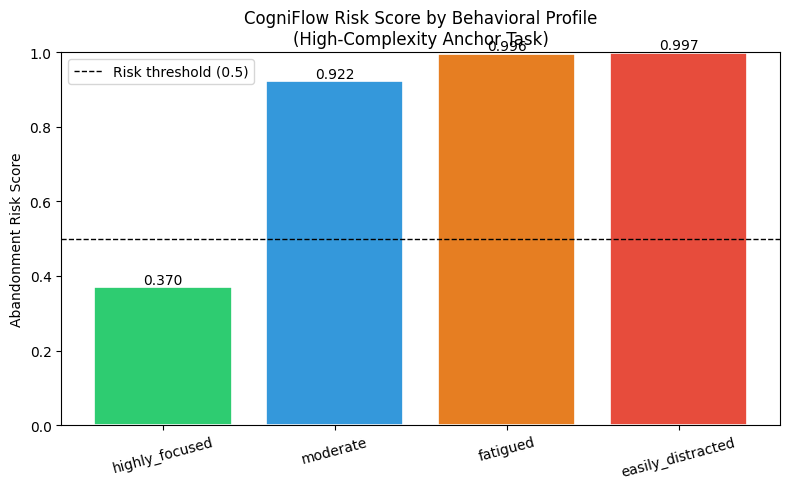

Saved stage3_profile_risk_scores.png


In [11]:
profile_colors = {
    'highly_focused': '#2ecc71',
    'moderate': '#3498db',
    'fatigued': '#e67e22',
    'easily_distracted': '#e74c3c'
}

plt.figure(figsize=(8, 5))
profiles = list(scores.keys())
values   = [scores[p] for p in profiles]
colors_bar = [profile_colors[p] for p in profiles]
bars = plt.bar(profiles, values, color=colors_bar, edgecolor='white', linewidth=1.2)
plt.axhline(0.5, color='black', linestyle='--', linewidth=1, label='Risk threshold (0.5)')
for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.01, f'{val:.3f}', ha='center', fontsize=10)
plt.ylim(0, 1.0)
plt.ylabel('Abandonment Risk Score')
plt.title('CogniFlow Risk Score by Behavioral Profile\n(High-Complexity Anchor Task)')
plt.xticks(rotation=15)
plt.legend()
plt.tight_layout()
plt.savefig('/kaggle/working/stage3_profile_risk_scores.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved stage3_profile_risk_scores.png')

## Step 10 - Save Model & Results

In [ ]:
import pickle

with open('/kaggle/working/cogniflow_xgboost.pkl', 'wb') as f:
    pickle.dump(model, f)

summary = {
    'auc_roc': round(auc, 4),
    'cv_auc_mean': round(cv_scores.mean(), 4),
    'cv_auc_std': round(cv_scores.std(), 4),
    'n_train': len(X_train),
    'n_test': len(X_test),
    'features': ALL_FEATURES,
    'monotonic_ordering': bool(is_monotonic),
    'profile_risk_scores': scores
}
pd.DataFrame([summary]).to_csv('/kaggle/working/stage3_summary.csv', index=False)

print('=== Final Results Summary ===')
print(f'AUC-ROC:        {auc:.4f}')
print(f'CV AUC (5-fold): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print(f'Monotonic order: {is_monotonic}')
print(f'\nSaved: cogniflow_xgboost.pkl, stage3_summary.csv')

=== Final Results Summary ===
AUC-ROC:        0.9578
CV AUC (5-fold): 0.9563 ± 0.0083
Monotonic order: True

Saved: cogniflow_xgboost.pkl, stage3_summary.csv
